In [13]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

In [15]:
data <- read.csv("extdata/mrna20k_lmci.csv", header=TRUE)

In [16]:
data_1 = data[,c(-1,-2)]

In [17]:
rownames(data_1) = data$index

In [18]:
data_2 = t(data_1)

In [19]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_lmci1<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype1")]
name_lmci2<-subtype_info$PID[which(subtype_info$SNF=="lmcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [20]:
## Add cell-type deconvolution results

In [42]:
mrna_lmci_deconv = read.delim("extdata/mrna_lmci_deconv.tsv")

In [43]:
row.names(mrna_lmci_deconv) = mrna_lmci_deconv$Cell.Type

In [158]:
# Only Consider the significant cells
mrna_lmci_deconv_sig = mrna_lmci_deconv[,c("T.cells.CD8", "T.cells.CD4.naive", "T.cells.CD4.memory.activated", "T.cells.CD4.memory.resting", "Neutrophils", "Eosinophils", "Monocytes", "NK.cells.resting", "Macrophages.M2")]

In [159]:
mrna_lmci_deconv_sig = as.data.frame(mrna_lmci_deconv_sig)

In [160]:
mrna_lmci_deconv_sig$groups = "lmci_1"

In [161]:
for(i in 1:200){
if(row.names(mrna_lmci_deconv_sig[i,]) %in% name_lmci2){
    mrna_lmci_deconv_sig$groups[i] = "lmci_2"
}
}

In [185]:
ind <- sapply(mrna_lmci_deconv_sig, is.numeric)
f = function(x){scale(x, center = FALSE)}
mrna_lmci_deconv_sig[ind] <- lapply(mrna_lmci_deconv_sig[ind],f)
formula = paste0(names(mrna_lmci_deconv_sig), collapse = ' + ')
formula = paste0("~", formula)
formula = formula(formula)
design2 = model.matrix(formula, data = mrna_lmci_deconv_sig)

In [187]:
ind

T.cells.CD8            T.cells.CD4.naive 
                        TRUE                         TRUE 
T.cells.CD4.memory.activated   T.cells.CD4.memory.resting 
                        TRUE                         TRUE 
                 Neutrophils                  Eosinophils 
                        TRUE                         TRUE 
                   Monocytes             NK.cells.resting 
                        TRUE                         TRUE 
              Macrophages.M2                       groups 
                        TRUE                        FALSE

In [188]:
fit1 = lmFit(data_2, design2)
fit2 = eBayes(fit1)

In [199]:
limma_result_fit = topTable(fit2,coef=11, n = Inf)
limma_result_fit$gene_symbol <- row.names(limma_result_fit)

Warning message:
“Removed 19988 rows containing missing values (geom_text_repel).”
Warning message:
“ggrepel: 32 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Saving 6.67 x 6.67 in image

Warning message:
“Removed 19988 rows containing missing values (geom_text_repel).”
Warning message:
“ggrepel: 32 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


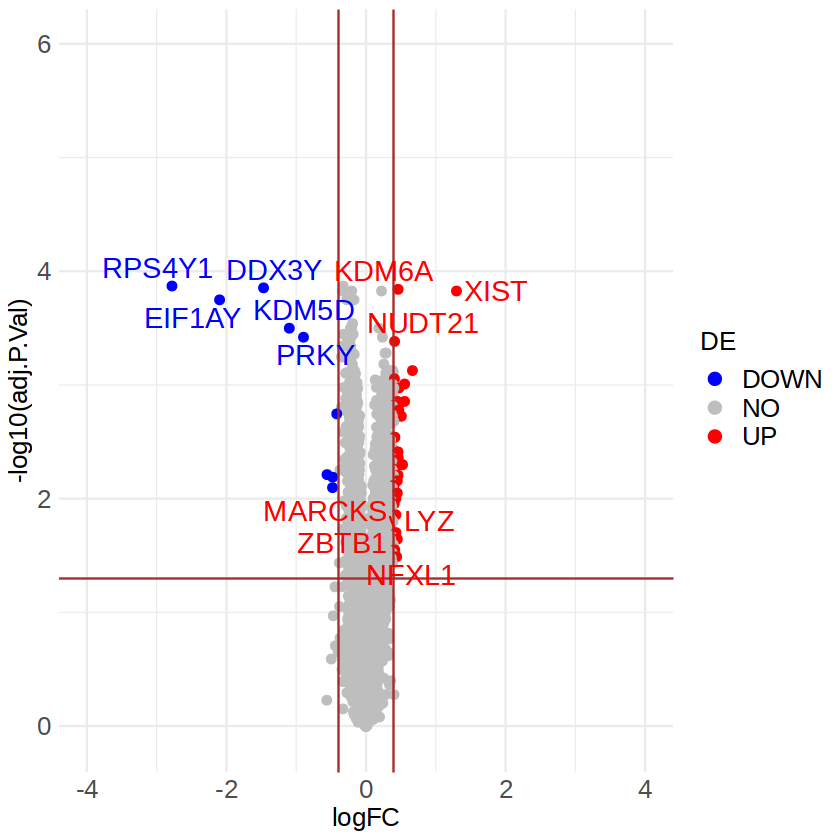

In [205]:
# plot volcano

fold_cutoff = 0.4

limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA
limma_result_fit$delabel[limma_result_fit$diffexpressed != "NO"] <- limma_result_fit$gene_symbol[limma_result_fit$diffexpressed != "NO"]

ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-4, 4) +ylim(-0.1,6) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=6,max.overlaps=10)

ggsave("figs/RP_2g.png",dpi=600)  

In [206]:
limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ] 

In [207]:
limma_DE

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
RPS4Y1,-2.7800368,8.254540,-5.934918,1.346992e-08,0.0001349147,9.30671006,RPS4Y1,DOWN,RPS4Y1
DDX3Y,-1.4679306,4.891695,-5.848520,2.097567e-08,0.0001400615,8.89691294,DDX3Y,DOWN,DDX3Y
KDM6A,0.4602519,4.557910,5.786078,2.881348e-08,0.0001442979,8.60329272,KDM6A,UP,KDM6A
XIST,1.2964339,3.207370,5.641386,5.961614e-08,0.0001492788,7.93129308,XIST,UP,XIST
EIF1AY,-2.0979434,6.045905,-5.540997,9.802370e-08,0.0001785101,7.47206954,EIF1AY,DOWN,EIF1AY
KDM5D,-1.0990723,4.836425,-5.388644,2.061139e-07,0.0003170714,6.78638581,KDM5D,DOWN,KDM5D
PRKY,-0.8956041,5.144640,-5.249628,4.011236e-07,0.0003806213,6.17283435,PRKY,DOWN,PRKY
NUDT21,0.4095493,5.387960,5.179695,5.581878e-07,0.0004141340,5.86864555,NUDT21,UP,NUDT21
TSPAN13,0.6653450,7.086430,4.945439,1.650709e-06,0.0007475772,4.87199692,TSPAN13,UP,TSPAN13


In [208]:
rownames(limma_DE)

[1] "RPS4Y1"   "DDX3Y"    "KDM6A"    "XIST"     "EIF1AY"   "KDM5D"   
 [7] "PRKY"     "NUDT21"   "TSPAN13"  "PNISR"    "GLCCI1"   "MYO5A"   
[13] "SLC35F5"  "CEP170"   "C1ORF27"  "ADO"      "SLC30A5"  "STX11"   
[19] "TTTY10"   "PCMTD1"   "UBR5"     "ARMCX3"   "C10ORF88" "PAPOLG"  
[25] "SOAT1"    "ZNRF2"    "GXYLT1"   "C2ORF69"  "FIGNL1"   "CASP8AP2"
[31] "UGT2B11"  "POLI"     "PTGDS"    "LRRN3"    "CD46"     "KIR3DL1" 
[37] "USP53"    "MEF2A"    "ZMAT1"    "VCPIP1"   "MARCKS"   "LYZ"     
[43] "ZBTB1"    "NFXL1"

In [209]:
write.csv(limma_DE,"DE_results/RP_limmaDE_LMCI.csv")